# Validation against SST data

Contains comparision of model output and ODYSSEA satellite data of sea surface temperature by calculating metrics and plotting data.

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from modules import metrics
from modules import read_files as read
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import glob
import h5py
import copernicusmarine


c:\Users\karoa\miniconda3\envs\default_env_api\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### test api

In [2]:

copernicusmarine.subset(
  dataset_id="IFREMER-ATL-SST-L4-NRT-OBS_FULL_TIME_SERIE",
  variables=["analysed_sst"],
  minimum_longitude=-17.688546216659866,
  maximum_longitude=-15.848276789993848,
  minimum_latitude=27.271544367353584,
  maximum_latitude=28.970254607352988,
  start_datetime="2023-01-13T00:00:00",
  end_datetime="2026-01-18T00:00:00",
  output_filename = "odyssea_api_test.nc",
)

INFO - 2026-08-10T09:48:46Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:Copernicus Marine username:Copernicus Marine password:

INFO - 2026-08-10T09:49:55Z - Selected dataset version: "201904"
INFO - 2026-08-10T09:49:55Z - Selected dataset part: "default"
INFO - 2026-08-10T09:50:01Z - Starting download. Please wait...
100%|██████████| 28/28 [00:04<00:00,  5.91it/s]
INFO - 2026-08-10T09:50:05Z - Successfully downloaded to odyssea_api_test.nc


ResponseSubset(file_path=WindowsPath('odyssea_api_test.nc'), output_directory=WindowsPath('.'), filename='odyssea_api_test.nc', file_size=16.458877862595422, data_transfer_size=166.21630534351144, variables=['analysed_sst'], coordinates_extent=[GeographicalExtent(minimum=-17.670000076293945, maximum=-15.850000381469727, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=27.290000915527344, maximum=28.969999313354492, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2023-01-13T00:00:00+00:00', maximum='2026-01-18T00:00:00+00:00', unit='iso8601', coordinate_id='time')], status='000', message='The request was successful.', file_status='DOWNLOADED')

### Configuration

In [ ]:
dir_odyssea = '../../data/ODYSSEA/odyssea_api_test.nc'
dir_model = '../../data/model_output/L1/WaterProperties_1_interp.hdf5'
outdir = '../../data/model_output/L1//'

### Read data and convert model output files to netcdf

In [4]:
# read satellite data
ds_odyssea = xr.open_dataset(dir_odyssea)
ds_odyssea['sst'] = ds_odyssea['analysed_sst'] - 273.15  # convert to celcius degrees
ds_odyssea

<xarray.Dataset> Size: 138MB
Dimensions:       (time: 1102, latitude: 85, longitude: 92)
Coordinates:
  * time          (time) datetime64[ns] 9kB 2023-01-13 2023-01-14 ... 2026-01-18
  * latitude      (latitude) float32 340B 27.29 27.31 27.33 ... 28.95 28.97
  * longitude     (longitude) float32 368B -17.67 -17.65 ... -15.87 -15.85
Data variables:
    analysed_sst  (time, latitude, longitude) float64 69MB 294.9 294.9 ... 292.9
    sst           (time, latitude, longitude) float64 69MB 21.8 21.78 ... 19.72
Attributes:
    Conventions:               CF-1.7, ACDD-1.3, ISO 8601
    institution:               Institut Francais de Recherche pour l'Exploita...
    history:                   Optimally interpolated SST originally produced...
    contact:                   emmanuelle.autret@ifremer.fr;jfpiolle@ifremer.fr
    references:                Product User Manual for L4 Odyssea Product ove...
    title:                     ODYSSEA North-East Atlantic Sea Surface Temper...
    source:                    Odyssea L4 processor
    copernicusmarine_version:  2.0.1

In [ ]:
# read and convert model output files
t, dates = read.MOHIDHdf5toNetcdf(dir_model, outdir=outdir)

# concat files with time

files = sorted(glob.glob('../../data/model_output/L1/WaterProperties_*.nc'))
datasets = [xr.open_dataset(f) for f in files]

# Stack them along a 'time' dimension
ds = xr.concat(datasets, dim='time')

# Close the underlying file handles now that data is in memory
for d in datasets:
    d.close()

# assign coordinate according to dates
with h5py.File(dir_model, 'r') as f:
    time_keys = sorted(f['Time'].keys())
    real_dates = []
    for k in time_keys:
        arr = f['Time'][k][:].ravel().astype(float)  
        y, m, d, H, M, S = arr[:6]
        real_dates.append(pd.Timestamp(int(y), int(m), int(d),
                                       int(H), int(M), int(round(S))))

ds = ds.assign_coords(time=('time', real_dates))

# remove fill values
ds = ds.where(ds.temperature > 0, drop=True)

# average to daily
ds = ds.resample(time='1D').mean() 

# rename coordinates
ds = ds.rename({'lat':'latitude'})
ds = ds.rename({'lon':'longitude'})

# interpolate model output to satellite data
ds = ds.interp(latitude=ds_odyssea.latitude, longitude=ds_odyssea.longitude)

ds

<xarray.Dataset> Size: 376kB
Dimensions:      (time: 6, latitude: 85, longitude: 92)
Coordinates:
  * time         (time) datetime64[us] 48B 2023-01-13 2023-01-14 ... 2023-01-18
  * latitude     (latitude) float32 340B 27.29 27.31 27.33 ... 28.93 28.95 28.97
  * longitude    (longitude) float32 368B -17.67 -17.65 -17.63 ... -15.87 -15.85
Data variables:
    temperature  (time, latitude, longitude) float32 188kB nan nan ... nan nan
    Bathymetry   (time, latitude, longitude) float32 188kB nan nan ... nan nan

### Compare

In [45]:
# Calculate metrics

temp = ds["temperature"]
sst = ds_odyssea["sst"]

# Keep only locations where both datasets have valid values
valid = temp.notnull() & sst.notnull()

temp_valid = temp.where(valid, drop=True)
sst_valid = sst.where(valid, drop=True)

rmse = metrics.rmse(temp_valid, sst_valid).mean()
bias = metrics.bias(temp_valid, sst_valid).mean()

print('RMSE:', rmse.item())
print('Bias:', bias.item())

RMSE: 0.7846657476294314
Bias: -0.654357392289027


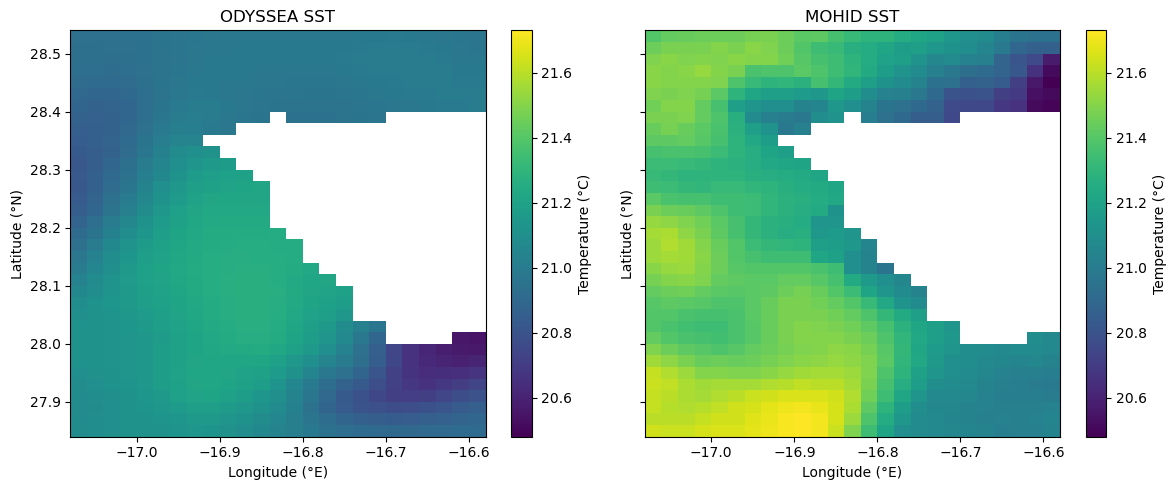

In [44]:
# visualize data
day = 1
index = day - 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# make sure color limits are same
vmin = min(
    temp_valid.isel(time=index).min().item(),
    sst_valid.isel(time=index).where(valid).min().item()
)
vmax = max(
    temp_valid.isel(time=index).where(valid).max().item(),
    sst_valid.isel(time=index).where(valid).max().item()
)


temp_valid.isel(time=index).plot(
    ax=axes[0],
   vmin=vmin,
   vmax=vmax,
    cbar_kwargs={'label': 'Temperature (°C)'}
)
axes[0].set_title("ODYSSEA SST")


sst_valid.isel(time=index).plot(
    ax=axes[1],
    vmin=vmin,
    vmax=vmax,
    cbar_kwargs={'label': 'Temperature (°C)'}
)
axes[1].set_title("MOHID SST")

# Common axis settings
for ax in axes:
    ax.set_xlim(-17.08, -16.58)
    ax.set_ylim(27.84, 28.54)
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")


plt.tight_layout()
plt.show()